In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

data = pd.read_csv("data.csv")
print(data.head())

     FILENAME                                 URL  URLLength  \
0  521848.txt    https://www.southbankmosaics.com         31   
1   31372.txt            https://www.uni-mainz.de         23   
2  597387.txt      https://www.voicefmradio.co.uk         29   
3  554095.txt         https://www.sfnmjournal.com         26   
4  151578.txt  https://www.rewildingargentina.org         33   

                       Domain  DomainLength  IsDomainIP  TLD  \
0    www.southbankmosaics.com            24           0  com   
1            www.uni-mainz.de            16           0   de   
2      www.voicefmradio.co.uk            22           0   uk   
3         www.sfnmjournal.com            19           0  com   
4  www.rewildingargentina.org            26           0  org   

   URLSimilarityIndex  CharContinuationRate  TLDLegitimateProb  ...  Pay  \
0               100.0              1.000000           0.522907  ...    0   
1               100.0              0.666667           0.032650  ...    0   
2 

In [2]:
print("Shape:", data.shape)
print("Columns:", list(data.columns))
print("Missing:", data.isnull().sum().sum())

Shape: (235795, 56)
Columns: ['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']
Missing: 0


In [3]:
print(data.describe())

           URLLength   DomainLength     IsDomainIP  URLSimilarityIndex  \
count  235795.000000  235795.000000  235795.000000       235795.000000   
mean       34.573095      21.470396       0.002706           78.430778   
std        41.314153       9.150793       0.051946           28.976055   
min        13.000000       4.000000       0.000000            0.155574   
25%        23.000000      16.000000       0.000000           57.024793   
50%        27.000000      20.000000       0.000000          100.000000   
75%        34.000000      24.000000       0.000000          100.000000   
max      6097.000000     110.000000       1.000000          100.000000   

       CharContinuationRate  TLDLegitimateProb    URLCharProb      TLDLength  \
count         235795.000000      235795.000000  235795.000000  235795.000000   
mean               0.845508           0.260423       0.055747       2.764456   
std                0.216632           0.251628       0.010587       0.599739   
min          

In [4]:
corr = data.corr(numeric_only=True)
cov = data.cov(numeric_only=True)

print("Correlation:\n", corr.head())
print("\nCovariance:\n", cov.head())

Correlation:
                       URLLength  DomainLength  IsDomainIP  URLSimilarityIndex  \
URLLength              1.000000      0.243091    0.277272           -0.421104   
DomainLength           0.243091      1.000000   -0.041398           -0.420694   
IsDomainIP             0.277272     -0.041398    1.000000           -0.121439   
URLSimilarityIndex    -0.421104     -0.420694   -0.121439            1.000000   
CharContinuationRate  -0.241104     -0.577425   -0.101307            0.572938   

                      CharContinuationRate  TLDLegitimateProb  URLCharProb  \
URLLength                        -0.241104          -0.016656    -0.245215   
DomainLength                     -0.577425           0.027209    -0.178104   
IsDomainIP                       -0.101307          -0.053220    -0.111769   
URLSimilarityIndex                0.572938           0.162042     0.571622   
CharContinuationRate              1.000000           0.237221     0.349810   

                      TLDLengt

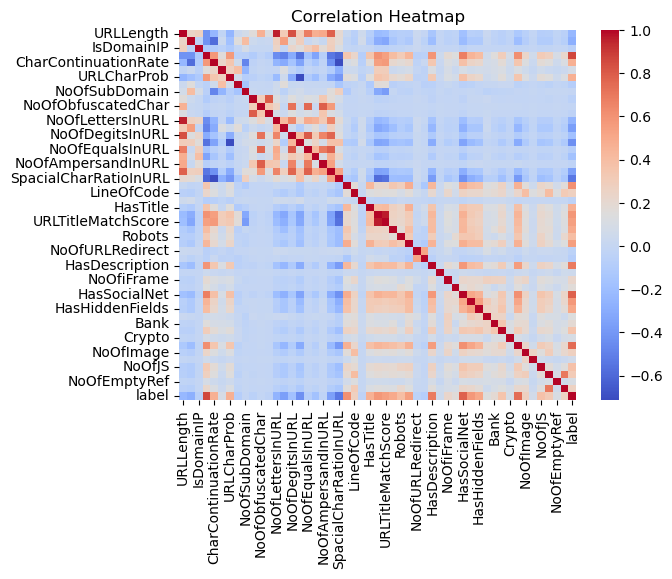

In [6]:
# Correlation Heatmap
plt.figure()
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()